<class 'pandas.core.frame.DataFrame'>
Index: 2242 entries, 2 to 2484
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   region           2242 non-null   object 
 1   year             2242 non-null   int64  
 2   value            2242 non-null   float64
 3   diagnosis        2242 non-null   object 
 4   region_standard  2242 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 105.1+ KB
None

Missing values by column:
 region             0
year               0
value              0
diagnosis          0
region_standard    0
dtype: int64

Number of unique regions: 85
Number of unique years: 14
Diagnosis categories: ['alcohol' 'drugs']

Number of duplicate rows: 0

Summary statistics for value:
 count    2242.000000
mean       65.826093
std        75.524067
min         0.000000
25%        10.700000
50%        34.800000
75%       104.975000
max       847.500000
Name: value, dtype: float64


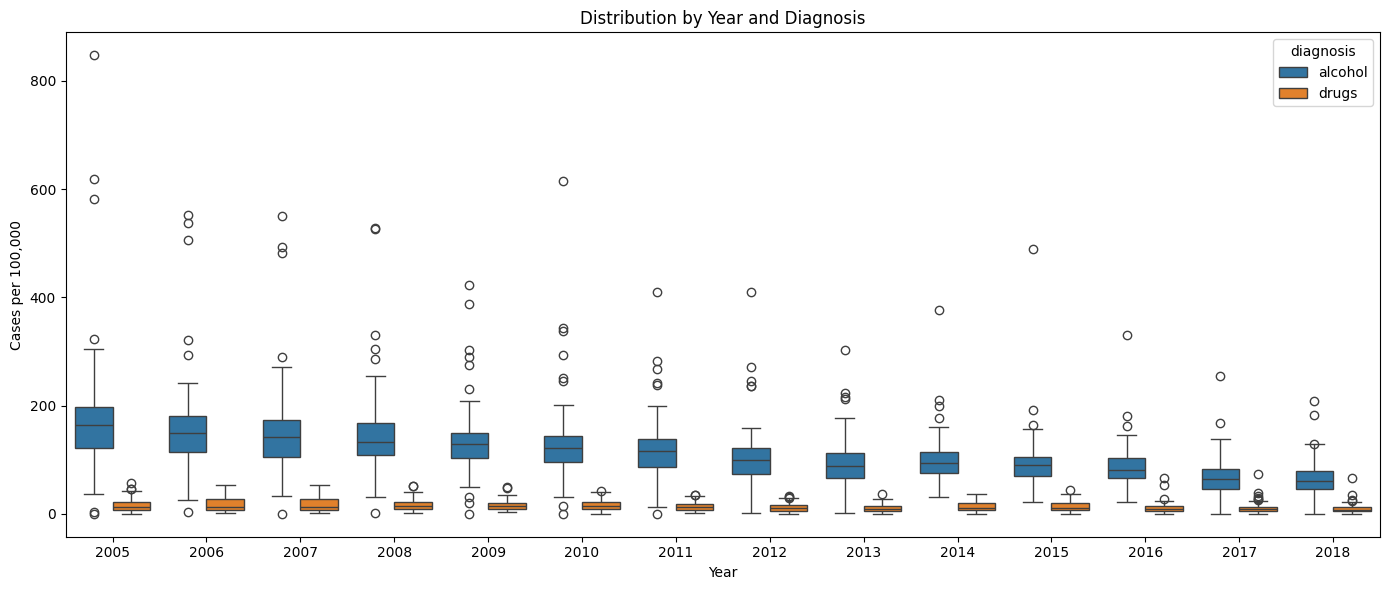

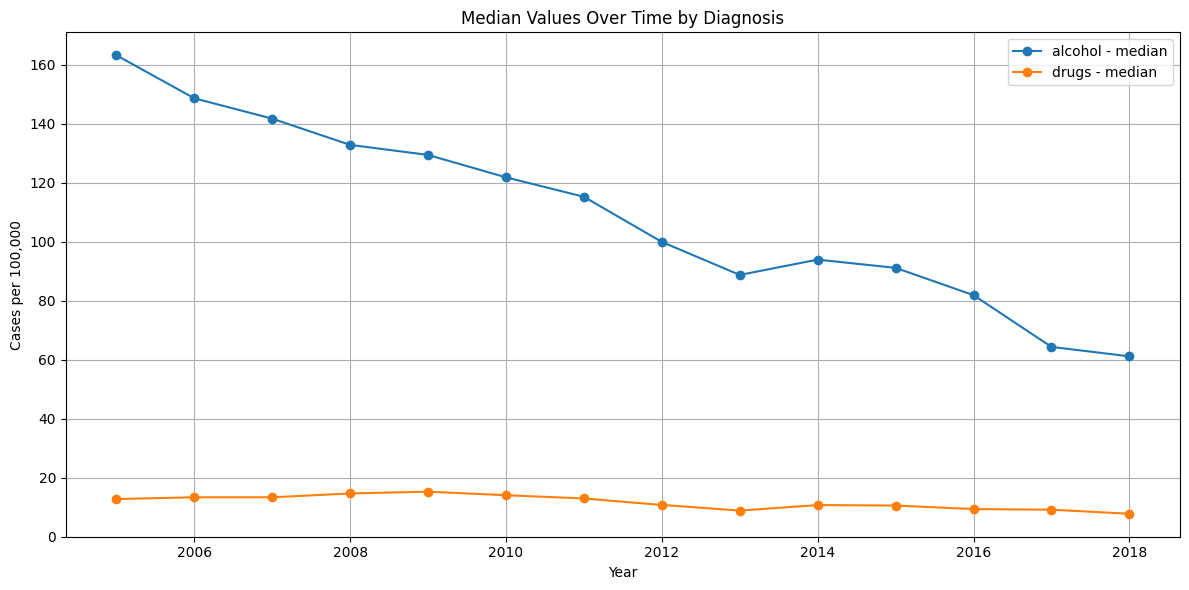

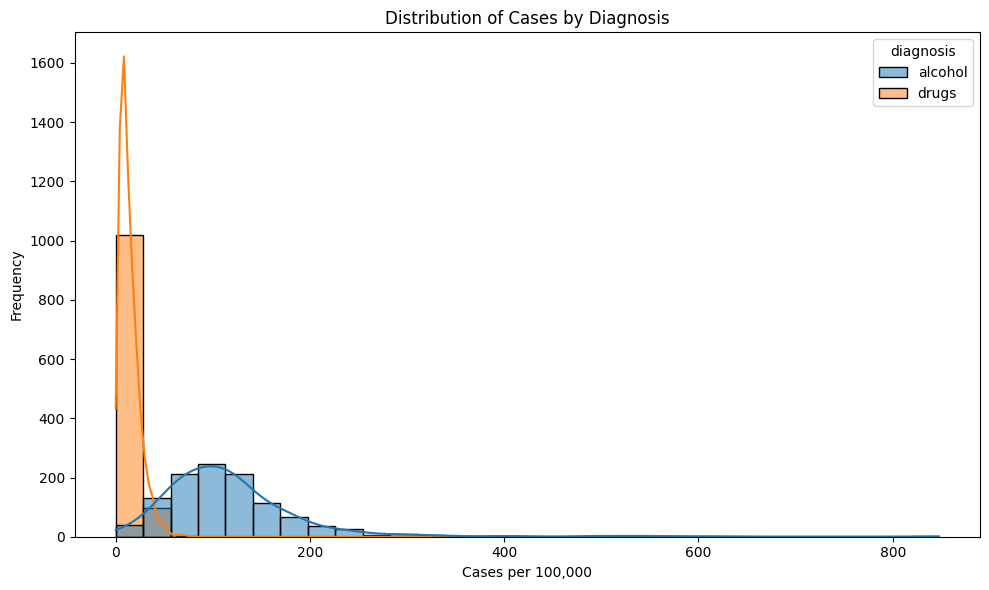

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data
file_path = "../../outputs/standardized_datasets/drug_alco_standardized.csv"
df = pd.read_csv(file_path)

# 2. Keep only rows with standardized region names
df = df[df["region_standard"].notna()]

# 3. Convert value column to numeric
df["value"] = pd.to_numeric(df["value"], errors="coerce")

# 4. Check data types and missing values
print(df.info())
print("\nMissing values by column:\n", df.isnull().sum())

# 5. Number of unique regions, years, and diagnoses
print("\nNumber of unique regions:", df["region_standard"].nunique())
print("Number of unique years:", df["year"].nunique())
print("Diagnosis categories:", df["diagnosis"].unique())

# 6. Check duplicates
duplicates = df.duplicated().sum()
print("\nNumber of duplicate rows:", duplicates)

# 7. Summary statistics
print("\nSummary statistics for value:\n", df["value"].describe())

# 8. Median values by year and diagnosis
median_all = df.groupby(["year", "diagnosis"])["value"].median().unstack()

# 9. Boxplot by year and diagnosis
plt.figure(figsize=(14,6))
sns.boxplot(x="year", y="value", hue="diagnosis", data=df)
plt.title("Distribution by Year and Diagnosis")
plt.xlabel("Year")
plt.ylabel("Cases per 100,000")
plt.tight_layout()
plt.show()

# 10. Median trends by diagnosis
plt.figure(figsize=(12,6))
for diag in median_all.columns:
    med = median_all[diag].dropna()
    plt.plot(med.index, med.values, marker="o", label=f"{diag} - median")

plt.title("Median Values Over Time by Diagnosis")
plt.xlabel("Year")
plt.ylabel("Cases per 100,000")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 11. Distribution of values
plt.figure(figsize=(10,6))
sns.histplot(data=df, x="value", hue="diagnosis", bins=30, kde=True)
plt.title("Distribution of Cases by Diagnosis")
plt.xlabel("Cases per 100,000")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# EDA of `drug_alco_standardized.csv`

## Data Description
- The dataset contains 696 observations across 85 regions.
- Time coverage: 2005–2020.
- Key variables: alcohol- and drug-related cases per 100,000 population.

---

## Data Types
- All variables are correctly formatted.
- The `value` column was converted to float.

---

## Missing Values
- No missing values were detected.

---

## Duplicates
- No duplicate records were found.

---

## Summary Statistics
- Mean: ~58 cases  
- Median: ~33 cases  
- Minimum: 0  
- Maximum: ~780  
- The distribution is strongly right-skewed  

This indicates that while most regions have relatively moderate levels, a small number of regions experience extremely high values.

---

## Visual Analysis
- **Boxplots by year and diagnosis** highlight variability and median differences across time and categories.  
- **Median trend plots** show how values evolve over time.  
- **Distribution plots** reveal concentration of observations in lower ranges with a long right tail.  

---

## Interpretation
- The strong right skew suggests significant regional inequality in addiction-related indicators.  
- A small number of regions with very high values may reflect concentrated social and public health issues.  
- Differences between alcohol- and drug-related cases indicate distinct underlying patterns across regions.

These features provide an important social-risk dimension that complements economic indicators such as income and poverty.

---

## Conclusion
The dataset is clean and suitable for further analysis.

The high variability and presence of extreme values suggest that these indicators will contribute meaningfully to clustering by capturing differences in regional social conditions.

In [2]:
df.to_csv("../../data/clean/drug_alco_AfterEDA.csv", index=False)